# Notebook 5 — Apprentissage Fédéré XGBoost (Entraînement Séquentiel + Soft Voting)

## Architecture fédérée

| Composant | Détail |
|-----------|--------|
| Modèle local | XGBoost `multi:softprob` (4 classes) |
| Stratégie | **Entraînement séquentiel** + **Soft Voting pondéré** |
| Clients | 5 (round-robin SubjectID — chacun a les 4 classes) |
| Données locales | train + val combinés |
| Modèle global | Enrichi séquentiellement par tous les clients à chaque round |
| Métrique | Log Loss multiclasse |

## Protocole par round

```
Round k :
  1. Ordre des clients mélangé aléatoirement (seed = 42 + k)
  2. Chaque client : xgb.train() depuis global_bst courant -> global_bst mis à jour immédiatement
  3. Serveur       : p_global = Σ (n_i/N) * p_i — soft voting sur les modèles finaux
  4. Serveur       : évalue p_global -> log_loss, accuracy, f1
  5. Répéter pour le round k+1
```

Après 20 rounds × 5 clients × 1 arbre = **100 arbres**, le modèle global a intégré
les données de tous les clients à chaque étape.

---

## 1. Imports & Configuration

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from datetime import datetime
import sys

sys.path.append('../src')

import xgboost as xgb
from flwr.simulation import run_simulation

from task import (
    load_data, get_test_dmatrix,
    XGBOOST_PARAMS, NUM_LOCAL_ROUNDS, NUM_CLIENTS,
)
from server_app import app as server_app, MODELS_PATH
from client_app import app as client_app
from sklearn.metrics import (
    confusion_matrix, classification_report,
    log_loss, accuracy_score, f1_score
)

plt.style.use('seaborn-v0_8-whitegrid'); sns.set_palette('Set2')

FIGURES_PATH     = Path('../results/figures')
METRICS_PATH     = Path('../results/metrics')
SUBMISSIONS_PATH = Path('../data/submission')
for p in [FIGURES_PATH, METRICS_PATH, SUBMISSIONS_PATH]: p.mkdir(parents=True, exist_ok=True)

print('✅ Imports OK')
print(f'   Clients : {NUM_CLIENTS}')


✅ Imports OK
   Clients : 5


## 2. Chargement des données

In [2]:
train_df, val_df, test_df, feature_cols, le = load_data()
CLASSES = list(le.classes_)

print(f'Train  : {train_df.shape}  |  Val : {val_df.shape}  |  Test : {test_df.shape}')
print(f'Features : {len(feature_cols)}')
print(f'Classes  : {CLASSES}')
print(f'Sujets train : {train_df["SubjectID"].nunique()}')


Train  : (2463, 208)  |  Val : (438, 208)  |  Test : (1068, 205)
Features : 204
Classes  : ['Mouth', 'Nasal', 'Skin', 'Stool']
Sujets train : 54


## 3. Création des clients

Partitionnement **round-robin par SubjectID** sur train + val combinés.  
Chaque client a les 4 classes → prédictions valides sur toutes les classes.

In [3]:
# Avec Flower, les clients sont gérés internalement par run_simulation().
# On précalcule les statistiques de partitionnement pour la visualisation.
full_df  = pd.concat([train_df, val_df], ignore_index=True)
subjects = sorted(full_df['SubjectID'].unique())

# n_train par client (utilisé pour pondérer le soft voting côté serveur)
client_n_train = {}
print(f'Partitionnement des {NUM_CLIENTS} clients (round-robin SubjectID) :')
for i in range(NUM_CLIENTS):
    c_subj = [s for j, s in enumerate(subjects) if j % NUM_CLIENTS == i]
    c_data = full_df[full_df['SubjectID'].isin(c_subj)]
    n_cls  = c_data['SampleType'].nunique()
    client_n_train[i] = len(c_data)
    print(f'  Client {i} : {len(c_subj):>2} sujets | {len(c_data):>4} échantillons | {n_cls} classes')


Partitionnement des 5 clients (round-robin SubjectID) :
  Client 0 : 14 sujets |  561 échantillons | 4 classes
  Client 1 : 13 sujets |  551 échantillons | 4 classes
  Client 2 : 13 sujets |  353 échantillons | 4 classes
  Client 3 : 13 sujets |  559 échantillons | 4 classes
  Client 4 : 13 sujets |  877 échantillons | 4 classes


## 4. Distribution des données par client

In [4]:
full_df  = pd.concat([train_df, val_df], ignore_index=True)
subjects = sorted(full_df['SubjectID'].unique())

client_stats = []
for i in range(NUM_CLIENTS):
    c_subj = [s for j,s in enumerate(subjects) if j%NUM_CLIENTS==i] # partitionnement round-robin par SubjectID
    c_data = full_df[full_df['SubjectID'].isin(c_subj)]
    stats  = {'Client': f'Client {i}', 'Sujets': len(c_subj), 'Échantillons': len(c_data)}

    for st in CLASSES: stats[st] = (c_data['SampleType']==st).sum()
    client_stats.append(stats)

stats_df = pd.DataFrame(client_stats)
stats_df


,Client,Sujets,Échantillons,Mouth,Nasal,Skin,Stool
0,Client 0,14,561,116,143,164,138
1,Client 1,13,551,129,132,162,128
2,Client 2,13,353,72,95,91,95
3,Client 3,13,559,123,134,168,134
4,Client 4,13,877,153,206,202,316


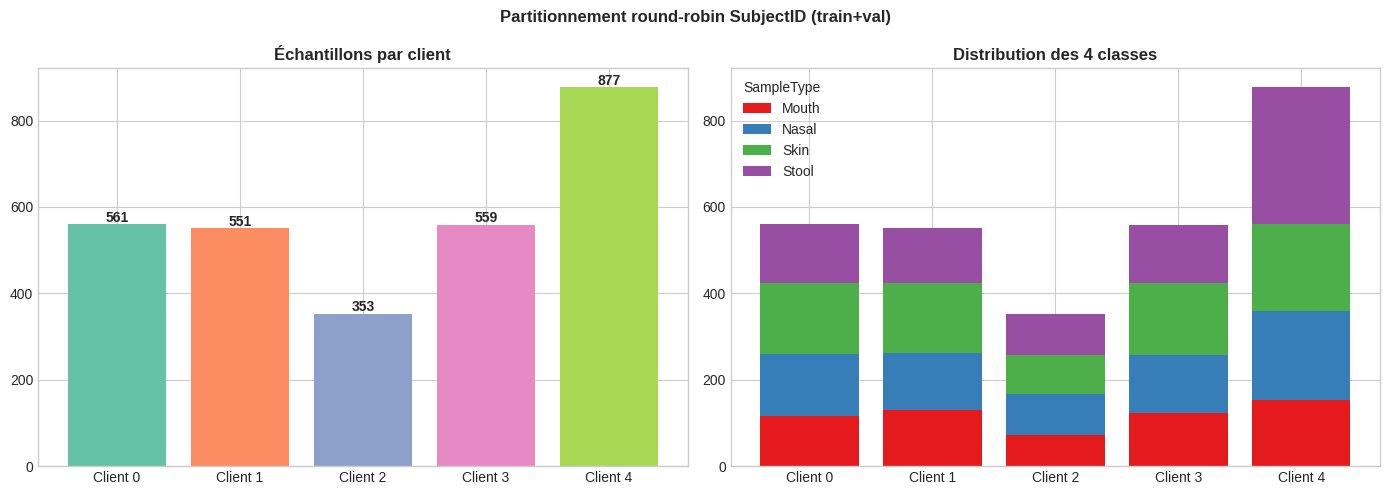

In [5]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
colors = sns.color_palette('Set2', NUM_CLIENTS)

# Barplot du nombre d'échantillons par client
bars = axes[0].bar(stats_df['Client'], stats_df['Échantillons'], color=colors)
axes[0].set_title('Échantillons par client', fontweight='bold')

# Annoter le nombre d'échantillons au-dessus de chaque barre
for bar, n in zip(bars, stats_df['Échantillons']):
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+5, str(n), ha='center', fontweight='bold')

# Barplot empilé de la distribution des classes par client    
bottom = np.zeros(NUM_CLIENTS)
for cls, col in zip(CLASSES, sns.color_palette('Set1', 4)):
    vals = stats_df[cls].values
    axes[1].bar(stats_df['Client'], vals, bottom=bottom, label=cls, color=col)
    bottom += vals
axes[1].set_title('Distribution des 4 classes', fontweight='bold')
axes[1].legend(title='SampleType')

plt.suptitle('Partitionnement round-robin SubjectID (train+val)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH/'05_client_data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Configuration paramètres fédération et XGBoost

In [6]:
N_SEMANTIC_ROUNDS = 20   # 20 × 5 clients × 1 arbre = 100 arbres
NUM_ROUNDS        = N_SEMANTIC_ROUNDS * NUM_CLIENTS   # 100 rounds Flower au total

print("Configuration Flower :")
print(f"  Rounds sémantiques     : {N_SEMANTIC_ROUNDS}")
print(f"  Rounds Flower (total)  : {NUM_ROUNDS}  ({N_SEMANTIC_ROUNDS} × {NUM_CLIENTS} clients)")
print(f"  Arbres / client / round: {NUM_LOCAL_ROUNDS}")
print(f"  Arbres total (global)  : {N_SEMANTIC_ROUNDS * NUM_CLIENTS * NUM_LOCAL_ROUNDS}")
print(f"  Agrégation             : Soft Voting pondéré (côté serveur)")
print()
for k, v in XGBOOST_PARAMS.items():
    print(f"  {k:<22} : {v}")


Configuration Flower :
  Rounds sémantiques     : 20
  Rounds Flower (total)  : 100  (20 × 5 clients)
  Arbres / client / round: 1
  Arbres total (global)  : 100
  Agrégation             : Soft Voting pondéré (côté serveur)

  objective              : multi:softprob
  num_class              : 4
  eval_metric            : mlogloss
  eta                    : 0.05
  max_depth              : 6
  subsample              : 0.8
  colsample_bytree       : 0.8
  min_child_weight       : 1
  tree_method            : hist
  nthread                : 8
  seed                   : 42


## 6. Simulation fédérée

In [7]:
print(f'⏰ Début : {datetime.now().strftime("%H:%M:%S")}')

# Lance la simulation Flower — même logique séquentielle + soft voting
run_simulation(
    server_app     = server_app,
    client_app     = client_app,
    num_supernodes = 1,   # client stateless, orchestre toutes les partitions via config
    backend_config = {"client_resources": {"num_cpus": 8, "num_gpus": 0}},
)

print(f'⏰ Fin   : {datetime.now().strftime("%H:%M:%S")}')
print('✅ Simulation Flower terminée — modèle et métriques sauvegardés')



            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower ServerApp, config: num_rounds=100, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client


⏰ Début : 13:07:35

SIMULATION FÉDÉRÉE FLOWER — Séquentiel + Soft Voting
  Clients        : 5
  Rounds sém.    : 20
  Rounds Flower  : 100
  Stratégie      : séquentiel (ordre mélangé chaque round)
  Agrégation     : Soft Voting pondéré par n_samples



INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 1 clients (out of 1)



── Round Sémantique 1/20 (étape 1/5) ── Partition 4 ──


INFO :      aggregate_fit: received 1 results and 0 failures
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 1 clients (out of 1)


...

(ClientAppActor pid=27688)   Client 3 | R20 |  559 samples | LogLoss=0.0378 | Acc=0.9932 | Arbres=98

── Round Sémantique 20/20 (étape 4/5) ── Partition 1 ──


INFO :      aggregate_fit: received 1 results and 0 failures
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 100]
INFO :      configure_fit: strategy sampled 1 clients (out of 1)


(ClientAppActor pid=27688)   Client 1 | R20 |  551 samples | LogLoss=0.0370 | Acc=0.9932 | Arbres=99

── Round Sémantique 20/20 (étape 5/5) ── Partition 2 ──


INFO :      aggregate_fit: received 1 results and 0 failures
[13:08:30] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 100 round(s) in 41.79s
INFO :      


(ClientAppActor pid=27688)   Client 2 | R20 |  353 samples | LogLoss=0.0366 | Acc=0.9932 | Arbres=100
  -> Global | LogLoss=0.0379 | Acc=0.9932 | F1=0.9932 | Arbres=100
  Best LogLoss : 0.0379
⏰ Fin   : 13:08:33
✅ Simulation Flower terminée — modèle et métriques sauvegardés


## 7. Résultats par round

In [8]:
history_df = pd.read_csv(METRICS_PATH / 'federated_metrics.csv')
best_round = history_df.loc[history_df['log_loss'].idxmin()]

display(history_df.round(4))
print(f'\n🏆 Meilleur round : {int(best_round["round"])}')
print(f'   Log Loss : {best_round["log_loss"]:.4f}')
print(f'   Accuracy : {best_round["accuracy"]:.4f}')
print(f'   F1-macro : {best_round["f1_macro"]:.4f}')


,round,log_loss,accuracy,f1_macro,n_trees
0,1,1.1842,0.2237,0.0914,5
1,2,0.8583,0.9749,0.9743,10
2,3,0.6507,0.9840,0.9842,15
3,4,0.5108,0.9886,0.9889,20
4,5,0.4033,0.9886,0.9889,25
5,6,0.3209,0.9886,0.9889,30
6,7,0.2563,0.9886,0.9889,35
7,8,0.2088,0.9886,0.9889,40
8,9,0.1695,0.9886,0.9889,45
9,10,0.1412,0.9886,0.9889,50



🏆 Meilleur round : 20
   Log Loss : 0.0379
   Accuracy : 0.9932
   F1-macro : 0.9932


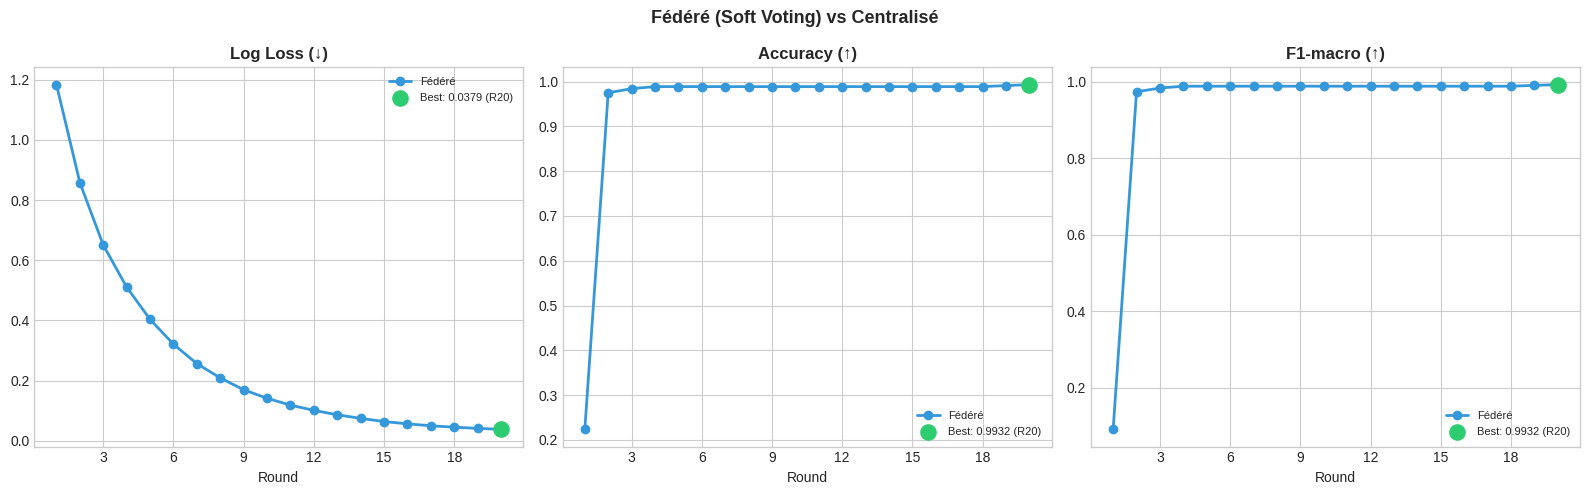

In [9]:
centralized_path = METRICS_PATH / 'centralized_metrics.csv'
best_cen = pd.read_csv(centralized_path).sort_values('log_loss').iloc[0] if centralized_path.exists() else None

fig, axes = plt.subplots(1,3, figsize=(16,5))
for ax, metric, title, better in zip(
    axes,
    ['log_loss','accuracy','f1_macro'],
    ['Log Loss (↓)','Accuracy (↑)','F1-macro (↑)'],
    ['min','max','max']
):
    # Tracer l'évolution du métrique au fil des rounds
    ax.plot(history_df['round'], history_df[metric],'o-', color='#3498db', lw=2, ms=6, label='Fédéré')
    # Tracer la référence centralisée (si disponible)
    if best_cen is not None and metric in best_cen.index:
        ref = best_cen[metric]
        ax.axhline(ref, color='#e74c3c', ls='--', lw=1.5, label=f'Centralisé ({ref:.4f})')

    # Trouver le meilleur résultat
    bi = history_df[metric].idxmin() if better=='min' else history_df[metric].idxmax()
    bv = history_df.loc[bi,metric]; br = history_df.loc[bi,'round']

    # Marquer le meilleur point
    ax.scatter([br],[bv], color='#2ecc71', s=120, zorder=5, label=f'Best: {bv:.4f} (R{int(br)})')
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Round')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=8)

plt.suptitle('Fédéré (Soft Voting) vs Centralisé', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH/'05_federated_metrics_per_round.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Évaluation du meilleur modèle global

In [10]:
# Charger le meilleur modèle global sauvegardé par la stratégie Flower
best_bst_loaded = xgb.Booster()
best_bst_loaded.load_model(str(MODELS_PATH / 'best_global_model.cubj'))
print(f'Arbres : {best_bst_loaded.num_boosted_rounds()}')

X_val    = val_df[feature_cols].values
y_val    = le.transform(val_df['SampleType'].values)
val_dmat = xgb.DMatrix(X_val, label=y_val)

# Prédictions directes du modèle global — résultat de l'entraînement séquentiel
final_proba = best_bst_loaded.predict(val_dmat).reshape(-1, len(CLASSES))
y_pred      = final_proba.argmax(axis=1)

print(f'Log Loss : {log_loss(y_val, final_proba, labels=list(range(len(CLASSES)))):.4f}')
print(f'Accuracy : {accuracy_score(y_val, y_pred):.4f}')
print(f'F1-macro : {f1_score(y_val, y_pred, average="macro"):.4f}')
print()
print(classification_report(y_val, y_pred, target_names=CLASSES))



Arbres : 100
Log Loss : 0.0366
Accuracy : 0.9932
F1-macro : 0.9932

              precision    recall  f1-score   support

       Mouth       0.98      1.00      0.99       100
       Nasal       0.99      1.00      1.00       103
        Skin       1.00      0.99      0.99       137
       Stool       1.00      0.99      0.99        98

    accuracy                           0.99       438
   macro avg       0.99      0.99      0.99       438
weighted avg       0.99      0.99      0.99       438



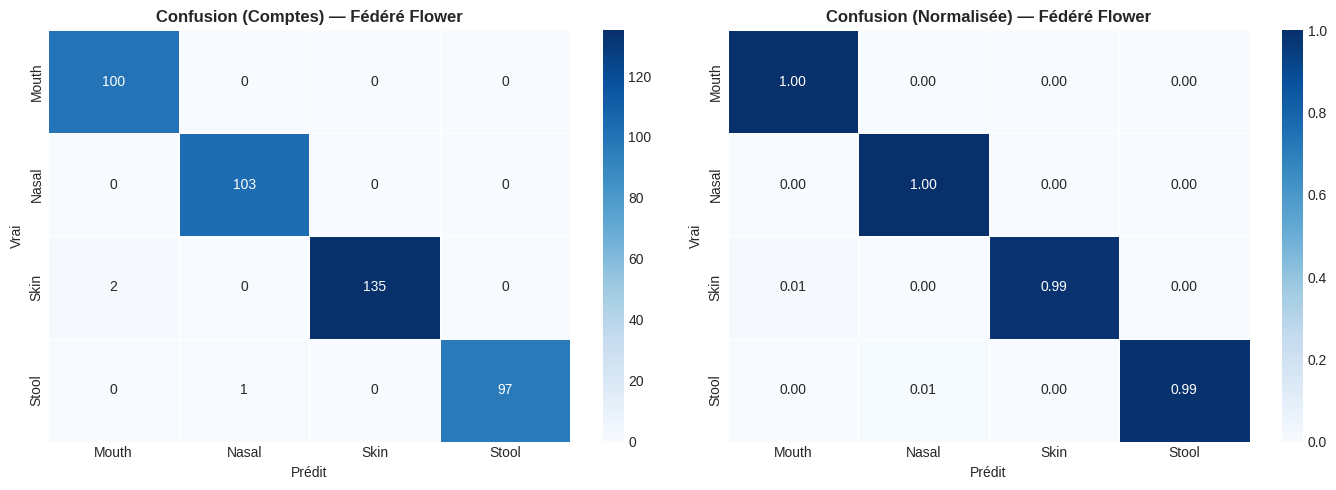

In [11]:
cm      = confusion_matrix(y_val, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, fmt, t in zip(axes, [cm, cm_norm], ['d', '.2f'], ['Comptes', 'Normalisée']):
    sns.heatmap(data, annot=True, fmt=fmt, xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues', ax=ax, linewidths=0.5)
    ax.set_title(f'Confusion ({t}) — Fédéré Flower', fontweight='bold')
    ax.set_ylabel('Vrai'); ax.set_xlabel('Prédit')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '05_confusion_matrix_federated.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Comparaison Fédéré vs Centralisé

In [12]:
if best_cen is not None:
    metrics_fed = {
        'log_loss': float(log_loss(y_val, final_proba, labels=list(range(len(CLASSES))))),
        'accuracy': float(accuracy_score(y_val, y_pred)),
        'f1_macro': float(f1_score(y_val, y_pred, average='macro')),
    }
    print('='*55)
    print(f'  {"Métrique":<14} | {"Fédéré":>8} | {"Centralisé":>10} | Δ')
    print(f'  {"-"*50}')
    for m in ['log_loss','accuracy','f1_macro']:
        fv=metrics_fed[m]; cv=best_cen[m]; d=fv-cv
        print(f'  {m:<14} | {fv:>8.4f} | {cv:>10.4f} | {"+" if d>0 else ""}{d:.4f}')
    print('='*55)

    ml=['log_loss','accuracy','f1_macro']
    tl=['Log Loss (↓)','Accuracy (↑)','F1-macro (↑)']
    x=np.arange(len(ml)); w=0.35
    fig, ax = plt.subplots(figsize=(10,6))
    b1=ax.bar(x-w/2,[metrics_fed[m] for m in ml],w,
              label='Fédéré (Soft Voting)',color='#3498db',alpha=0.85)
    b2=ax.bar(x+w/2,[best_cen[m] for m in ml],w,
              label=f'Centralisé ({best_cen["model"]})',color='#e74c3c',alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(tl)
    ax.set_title('Fédéré vs Centralisé — Validation set',fontweight='bold',fontsize=13)
    ax.legend()
    for bar in [*b1,*b2]:
        ax.text(bar.get_x()+bar.get_width()/2.,bar.get_height()+0.003,
                f'{bar.get_height():.4f}',ha='center',va='bottom',fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGURES_PATH/'05_federated_vs_centralized.png',dpi=150,bbox_inches='tight')
    plt.show()


## 10. Calibration en température

Le log_loss est sensible à la **confiance** des probabilités.  
La calibration en température trouve un scalaire T tel que :

```
p_cal(x) = softmax(log(p(x)) / T)
```

- T < 1 → probabilités plus tranchées (plus confiantes)
- T > 1 → probabilités plus douces (moins confiantes)

T est optimisé sur le val set (grid search borné) puis appliqué au test.

In [13]:
from scipy.optimize import minimize_scalar
from scipy.special import softmax as scipy_softmax

def apply_temperature(proba: np.ndarray, T: float) -> np.ndarray:
    log_p = np.log(np.clip(proba, 1e-10, 1.0))
    return scipy_softmax(log_p / T, axis=1)

# ── Calibration en température sur le val set ────────────────────────────────
# Utilise le modèle global
val_proba_raw = best_bst_loaded.predict(val_dmat).reshape(-1, len(CLASSES))

result = minimize_scalar(
    lambda T: log_loss(y_val, apply_temperature(val_proba_raw, T), labels=list(range(len(CLASSES)))),
    bounds=(0.1, 5.0), method='bounded'
)

T_opt = result.x
print(f'Température optimale : T = {T_opt:.4f}')
print(f'Log Loss brut        : {log_loss(y_val, val_proba_raw):.4f}')
print(f'Log Loss calibré     : {result.fun:.4f}')

# ── Prédictions test calibrées ───────────────────────────────────────────────
test_dmat        = get_test_dmatrix(test_df, feature_cols)
y_test_proba_raw = best_bst_loaded.predict(test_dmat).reshape(-1, len(CLASSES))
y_test_proba     = apply_temperature(y_test_proba_raw, T_opt)


Température optimale : T = 0.6979
Log Loss brut        : 0.0366
Log Loss calibré     : 0.0261


## 11. Soumission

In [15]:
sample_sub = pd.read_csv('../data/submission/SampleSubmission.csv')
COLS       = sample_sub.columns.tolist()
CLASSES    = COLS[1:]

proba_df = pd.DataFrame(y_test_proba, columns=CLASSES)
proba_df.insert(0, 'filename', test_df['filename'].values)

submission = sample_sub[['filename']].merge(proba_df, on='filename', how='left')
n_missing  = submission[CLASSES[0]].isnull().sum()
if n_missing > 0:
    for cls in CLASSES: submission[cls] = submission[cls].fillna(1 / len(CLASSES))
    print(f'⚠️  {n_missing} manquant(s) -> uniforme')

submission['filename'] = submission['filename'].str.replace('.mgb', '', regex=False)
submission = submission[COLS]

assert len(submission) == len(sample_sub)
assert submission.isnull().sum().sum() == 0
assert (submission[CLASSES].sum(axis=1) - 1.0).abs().max() < 1e-5

sub_path = SUBMISSIONS_PATH / 'submission_federated.csv'
submission.to_csv(sub_path, index=False)
print(f'✅ Soumission : {sub_path}')
submission.head()


✅ Soumission : ../data/submission/submission_federated.csv


,filename,Mouth,Nasal,Skin,Stool
0,ID_YBNOYC,0.000157,0.999036,0.000393,0.000414
1,ID_HPVLUO,0.000117,0.000293,0.000169,0.999421
2,ID_DQGGYD,0.000455,0.995286,0.003694,0.000565
3,ID_XZBUJB,0.000332,0.997051,0.002021,0.000596
4,ID_KRPYRQ,0.000352,0.996718,0.002382,0.000548
